In [9]:
import pandas as pd
import numpy as np
import os

def evaluate_logs(n_patients):
    # --- 1. Chọn các epsilon cần thiết ---
    selected_eps = ["0.0", "0.3", "0.7", "1.0"]

    # --- 2. Build filenames cho các epsilon ---
    greedy_files = {
    eps: f"../../data/evaluate_data/{n_patients}_greedy_epsilon_{eps.replace('.', '_')} _event_log.csv"
    for eps in selected_eps
}


    # --- 3. Load các greedy logs ---
    greedy_logs = {eps: pd.read_csv(path) for eps, path in greedy_files.items()}

    # --- 4. Load DQN log ---
    dqn_log = pd.read_csv(f"../../data/evaluate_data/{n_patients}_dqn40000_event_log.csv")

    # --- 5. Kết hợp tất cả logs ---
    all_logs = greedy_logs.copy()
    all_logs['dqn_0_1'] = dqn_log

    results = {}

    # --- 6. Tính waiting_time & process_time ---
    for key, log in all_logs.items():
        log['waiting_time'] = log['start_timestamp'] - log['request_timestamp']

        process_times = []
        for pid in log['patient_id'].unique():
            temp = log[log['patient_id'] == pid]
            process_times.append(temp['end_timestamp'].max() - temp['start_timestamp'].min())

        results[key] = {
            "waiting_time": log['waiting_time'].mean(),
            "process_time": np.mean(process_times),
        }

    return results

C:\Users\acer\AppData\Local\Temp\ipykernel_6620\148078960.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for eps, subdf in df.groupby("epsilon"):


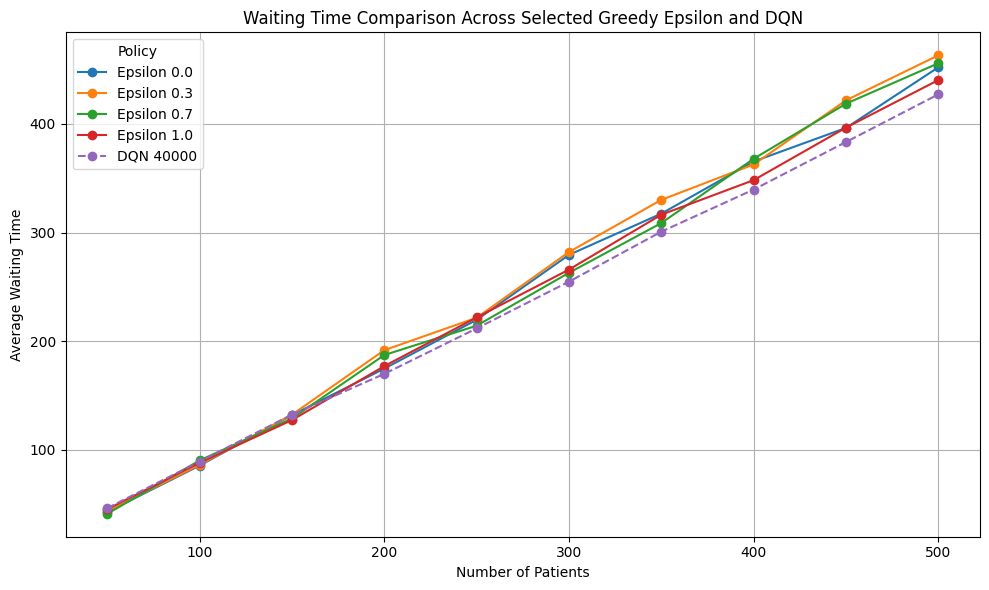

C:\Users\acer\AppData\Local\Temp\ipykernel_6620\148078960.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for eps, subdf in df.groupby("epsilon"):


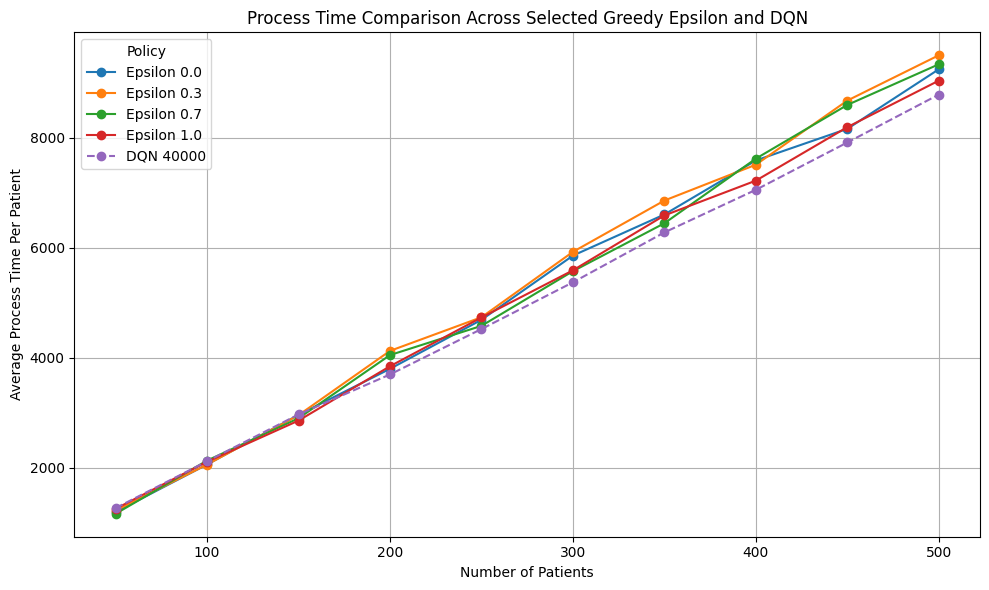

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

# --- Evaluate for multiple numbers of patients ---
all_rows = []

for n in range(50, 501, 50):
    stats = evaluate_logs(n)   # {"0.0": {...}, "0.3": {...}, "0.7": {...}, "1.0": {...}, "dqn_0_1": {...}}
    
    for eps, metrics in stats.items():
        row = {
            "n_patients": n,
            "epsilon": eps,
            "waiting_time": metrics["waiting_time"],
            "process_time": metrics["process_time"],
        }
        all_rows.append(row)

df = pd.DataFrame(all_rows)

# --- Sort epsilon values numerically; DQN at end ---
epsilon_order = ["0.0", "0.3", "0.7", "1.0", "dqn_0_1"]
df["epsilon"] = pd.Categorical(df["epsilon"], categories=epsilon_order, ordered=True)
df = df.sort_values(["epsilon", "n_patients"])

# --- 1. Plot Waiting Time ---
plt.figure(figsize=(10, 6))

for eps, subdf in df.groupby("epsilon"):
    label = "DQN 40000" if eps.startswith("dqn") else f"Epsilon {eps}"
    style = '--' if eps.startswith("dqn") else '-'
    plt.plot(
        subdf["n_patients"],
        subdf["waiting_time"],
        marker='o',
        linestyle=style,
        label=label
    )

plt.xlabel("Number of Patients")
plt.ylabel("Average Waiting Time")
plt.title("Waiting Time Comparison Across Selected Greedy Epsilon and DQN")
plt.legend(title="Policy")
plt.grid(True)
plt.tight_layout()
plt.show()

# --- 2. Plot Process Time ---
plt.figure(figsize=(10, 6))

for eps, subdf in df.groupby("epsilon"):
    label = "DQN 40000" if eps.startswith("dqn") else f"Epsilon {eps}"
    style = '--' if eps.startswith("dqn") else '-'
    plt.plot(
        subdf["n_patients"],
        subdf["process_time"],
        marker='o',
        linestyle=style,
        label=label
    )

plt.xlabel("Number of Patients")
plt.ylabel("Average Process Time Per Patient")
plt.title("Process Time Comparison Across Selected Greedy Epsilon and DQN")
plt.legend(title="Policy")
plt.grid(True)
plt.tight_layout()
plt.show()

---

In [33]:
dqn_20_log = pd.read_csv("../../data/evaluate_data/20_dqn_event_log.csv")
greedy_20_log = pd.read_csv("../../data/evaluate_data/20_greedy_epsilon_event_log.csv")

In [34]:
dqn_20_log = dqn_20_log.sort_values(['request_timestamp'])
dqn_20_log['waiting_time'] = dqn_20_log['start_timestamp'] - dqn_20_log['request_timestamp']

In [35]:
greedy_20_log = greedy_20_log.sort_values(['request_timestamp'])
greedy_20_log['waiting_time'] = greedy_20_log['start_timestamp'] - greedy_20_log['request_timestamp']

In [37]:
evaluate_logs(20)

{'greedy_waiting_time': np.float64(13.912603662549884),
 'dqn_waiting_time': np.float64(18.454919749217186),
 'greedy_process_time': np.float64(629.989030123396),
 'dqn_process_time': np.float64(708.9361936413309)}

In [ ]:
evaluate_logs(20)   

{'greedy_waiting_time': np.float64(13.912603662549884),
 'dqn_waiting_time': np.float64(18.454919749217186),
 'greedy_process_time': np.float64(629.989030123396),
 'dqn_process_time': np.float64(708.9361936413309)}

In [23]:
dqn_20_log = dqn_20_log.sort_values(['waiting_time'], ascending=False)

In [24]:
dqn_20_log.head(20)

,patient_id,activity_name,request_timestamp,start_timestamp,end_timestamp,gender,marital_status,blood_result_ready,urine_result_ready,queue_status,waiting_time
391,19,General Ultrasound,769.537733,1038.803182,1079.794664,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",269.265448
370,18,General Ultrasound,743.477703,996.568292,1038.803182,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",253.090590
349,17,General Ultrasound,709.536507,951.368154,996.568292,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",241.831647
311,15,General Ultrasound,681.996338,907.043815,951.368154,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",225.047477
330,16,General Ultrasound,652.974371,861.608661,907.043815,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",208.634290
389,19,In-depth Eye Examination,522.428109,723.174835,750.357436,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",200.746727
290,14,General Ultrasound,623.056143,814.836814,861.608661,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",191.780671
368,18,In-depth Eye Examination,503.964675,691.922836,723.174835,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",187.958162
347,17,In-depth Eye Examination,479.641244,661.990064,691.922836,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",182.348820
309,15,In-depth Eye Examination,459.026373,635.010555,661.990064,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",175.984182


In [25]:
greedy_20_log = greedy_20_log.sort_values(['waiting_time'], ascending=False)

In [26]:
greedy_20_log.head(20)

,patient_id,activity_name,request_timestamp,start_timestamp,end_timestamp,gender,marital_status,blood_result_ready,urine_result_ready,queue_status,waiting_time
256,12,General Ultrasound,778.328641,1032.556211,1072.443031,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",254.227570
392,19,General Ultrasound,825.605628,1072.443031,1118.306708,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",246.837403
331,16,General Ultrasound,747.941330,986.477452,1032.556211,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",238.536123
328,16,In-depth Eye Examination,421.234408,646.834058,675.249371,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",225.599650
386,19,In-depth Eye Examination,456.707497,675.249371,702.371266,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",218.541873
368,18,General Ultrasound,723.408267,934.698256,986.477452,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",211.289989
251,12,In-depth Eye Examination,414.181024,615.152919,646.834058,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",200.971894
294,14,General Ultrasound,691.897221,887.602145,934.698256,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",195.704923
350,17,General Ultrasound,660.847862,837.452105,887.602145,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",176.604243
176,8,General Ultrasound,624.609577,798.499771,837.452105,NaN,NaN,NaN,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",173.890194


In [28]:
dqn_20_log[dqn_20_log['activity_name'] == "Blood Test"]

,patient_id,activity_name,request_timestamp,start_timestamp,end_timestamp,gender,marital_status,blood_result_ready,urine_result_ready,queue_status,waiting_time
55,2,Blood Test,246.285491,246.285491,256.337807,NaN,NaN,348.146017,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
15,0,Blood Test,284.400738,284.400738,293.951089,NaN,NaN,386.541080,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
232,11,Blood Test,716.105322,716.105322,725.635097,NaN,NaN,816.591118,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
36,1,Blood Test,324.998570,324.998570,333.806627,NaN,NaN,427.697369,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
251,12,Blood Test,762.472528,762.472528,772.321399,NaN,NaN,865.970314,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
95,4,Blood Test,370.968539,370.968539,381.242104,NaN,NaN,471.970556,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
271,13,Blood Test,814.836814,814.836814,824.202286,NaN,NaN,918.546503,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
114,5,Blood Test,420.646403,420.646403,430.994782,NaN,NaN,521.704219,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
291,14,Blood Test,861.608661,861.608661,872.151037,NaN,NaN,964.424049,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0
76,3,Blood Test,457.370005,457.370005,466.705123,NaN,NaN,560.021100,NaN,"{""Registration"": 0, ""Payment"": 0, ""Get Triage ...",0.0


In [ ]:
for i in range(20):
    temp_log = dqn_20_log['dqn_']

---

In [5]:
import json
with open("../../data/raw_data/activity_info.json", "r", encoding="utf-8") as f:
    activity_info = json.load(f)

In [10]:
throught_put = []
for key, value in activity_info.items():
    if key == "Payment":
        throught_put.append((value["mean_time"]["Cash"] + value["mean_time"]["Credit"]) /  2 / value["staff"])
    else:
        throught_put.append(value["mean_time"]/value["staff"])
    

In [213]:
throught_put

[2.5,
 2.0,
 1.0,
 5.0,
 10.0,
 15.0,
 15.0,
 15.0,
 15.0,
 15.0,
 10.0,
 10.0,
 30.0,
 20.0,
 20.0,
 30.0,
 45.0,
 30.0,
 20.0,
 20.0,
 10.0]

In [181]:
queues = np.array([np.random.poisson(0.15 * tp) for tp in throught_put])
queues

array([ 1,  0,  0,  0,  0,  1,  1,  1,  3,  2,  2,  3,  3,  2,  3,  6, 12,
        5,  8,  3,  0])

In [182]:
dqn_2000_log = pd.read_csv("../../data/evaluate_data/2000_dqn_event_log.csv")

In [188]:
import ast
def convert_str_queue_2_list(queue_str: str):
    queue_dict = ast.literal_eval(queue_str)
    return list(queue_dict.values())


In [ ]:
set(dqn_2000_log.loc[0,"queue_status"])

In [208]:
import ast
import pandas as pd

dqn_2000_log = pd.read_csv("../../data/evaluate_data/500_greedy_epsilon_event_log.csv")

def convert_str_queue_2_set(queue_str: str):
    # Parse string to dict (or list) safely
    parsed = ast.literal_eval(queue_str)
    # Nếu parsed là dict, lấy values; nếu là list, dùng trực tiếp
    if isinstance(parsed, dict):
        vals = list(parsed.values())
    else:
        vals = list(parsed)
    # Nếu values là string số, chuyển về int (nếu cần)
    try:
        vals = [int(v) for v in vals]
    except Exception:
        pass
    return set(vals)

# Áp dụng
dqn_2000_log["queue_status_set"] = dqn_2000_log["queue_status"].apply(convert_str_queue_2_set)

In [209]:
# Chuyển set -> tuple (hashable)
dqn_2000_log["queue_status_tuple"] = dqn_2000_log["queue_status_set"].apply(lambda x: tuple(sorted(x)))

# Lấy unique
unique_queues = dqn_2000_log["queue_status_tuple"].unique()
print(unique_queues)


[(0, 1) (0, 1, 2) (0, 1, 3) ... (0, 1, 15, 19, 159) (0, 19) (0, 1, 18)]


In [210]:
for i in unique_queues:
    print(i)

(0, 1)
(0, 1, 2)
(0, 1, 3)
(0, 1, 4)
(0, 2, 3, 5)
(0, 1, 2, 6)
(0, 1, 2, 5)
(0, 1, 2, 4)
(0, 1, 2, 3, 5)
(0, 1, 3, 4, 5)
(0, 1, 2, 3, 4, 6)
(0, 1, 2, 4, 5, 6, 7)
(0, 1, 2, 4, 5, 7)
(0, 1, 2, 5, 6)
(0, 2)
(0, 1, 2, 3, 4)
(0, 1, 2, 3, 6)
(0, 1, 5, 6)
(0, 1, 2, 3, 4, 5, 6)
(0, 1, 2, 4, 5, 6)
(0, 1, 2, 4, 5, 8)
(0, 1, 2, 3, 5, 7, 8)
(0, 1, 2, 3)
(0, 1, 2, 3, 7)
(0, 1, 2, 4, 5)
(0, 1, 2, 3, 4, 5)
(0, 1, 3, 5)
(0, 1, 2, 3, 4, 5, 6, 9)
(0, 1, 2, 3, 4, 5, 7, 8)
(0, 1, 2, 3, 7, 8, 9)
(0, 1, 2, 3, 4, 5, 8)
(0, 1, 2, 3, 5, 7, 8, 9)
(0, 1, 2, 3, 7, 8, 10)
(0, 1, 2, 3, 5, 6, 7, 8)
(0, 1, 2, 4, 5, 6, 8, 9)
(0, 1, 2, 3, 5, 7, 8, 11)
(0, 1, 2, 4, 7)
(0, 1, 2, 3, 6, 8)
(0, 1, 2, 3, 4, 6, 8, 9)
(0, 1, 2, 3, 5, 6, 7, 9, 10)
(0, 1, 2, 4, 6)
(0, 1, 2, 3, 5, 6)
(0, 1, 2, 5, 6, 7)
(0, 1, 2, 3, 6, 7, 8)
(0, 1, 2, 3, 4, 7, 8)
(0, 1, 2, 3, 4, 6, 7, 8, 9)
(0, 1, 2, 3, 4, 8, 10, 12)
(0, 1, 3, 4)
(0, 1, 2, 3, 4, 6, 7, 9, 10)
(0, 1, 2, 3, 4, 8, 9, 13)
(0, 1, 2, 3, 4, 6, 7, 8)
(0, 1, 2, 3, 5, 6, 8, 9)
(0, 1, 2, 3, 4

In [ ]:
dqn_2000_log.head(f)

In [ ]:
# Hàng chờ của 2000 -> Mà tối đa là 0,1,2? -> Quá ngắn ? Lỗi gì nhỉ?. 